# Compare output grids — varying `M` in `M * delta > tf`

`M` controls how many output time steps are produced:
- larger `M` → smaller `delta` → more output points (finer time grid)
- smaller `M` → larger `delta` → fewer output points (coarser time grid)

All runs use the same `nz` and march at the same fine `dt_stab`.
Only the output stride `n_true = n_fine // M + 1` changes.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)

Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  n_fine=128000  dt=1.5625e-04
n_true=401  delta=0.062656  320*delta=20.0500 > tf=20.0: True
n_out=319  (excluding t=0)
t[0]=0.0000  t[-1]=19.9873  n_t=320
Solver(k1=1.0, k2=2.0, z_dis=1.0, Pda=1.0, Lz=16.0, nz=640, tf=20.0, M=320, n_true=401, delta=0.062656, device='cuda')
Keys: ['U', 'U_raw', 'W', 'dataset', 'interp', 'interp_lin', 'interp_pw', 'kratio', 'stau', 't', 'z', 'z_dis']


/tmp/ipykernel_349/2287032977.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()


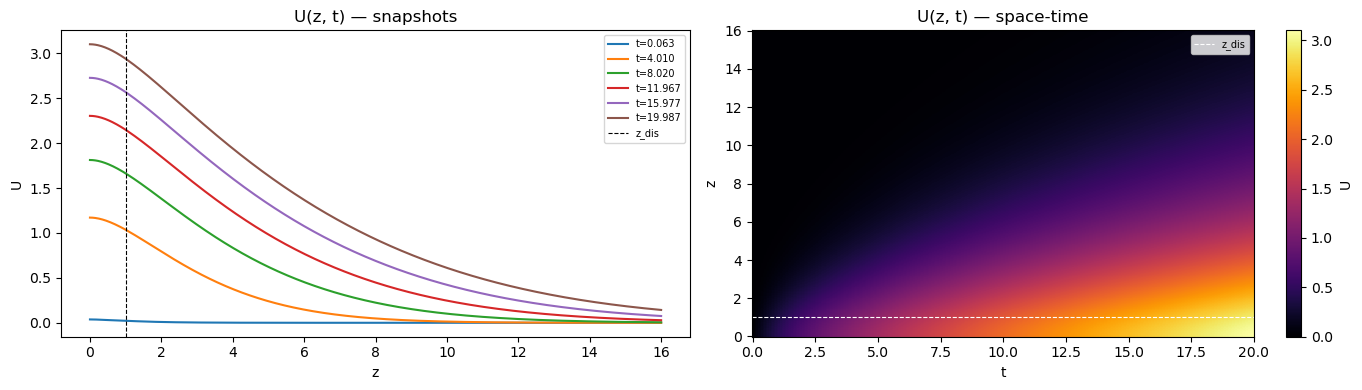

Dataset saved to ./data/2layer_k11.0_k22.0_nz640_M320.pt


In [11]:
%run func_defs.ipynb
%run focus1_v4.ipynb

## Parameters

Edit `M_list` to add or remove values to compare.

In [12]:
k1, k2  = 1.0, 2.0
z_dis   = 1.0
Pda     = 1.0
Lz      = 16.0
nz      = 640
tf      = 20.0

M_list  = [320, 160, 80, 40]   # values to compare

device  = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}  nz={nz}  tf={tf}')

device: cuda  nz=640  tf=20.0


## Run solver for each `M`

In [13]:
solvers = {}   # M -> Solver

for M in M_list:
    print(f'\n=== M={M} ===')
    solvers[M] = Solver(
        k1=k1, k2=k2, z_dis=z_dis, Pda=Pda,
        Lz=Lz, nz=nz, tf=tf,
        device=device, M=M, verbose=True,
    )
    t = solvers[M]['t']
    print(f'  n_true={solvers[M]._n_true}  delta={solvers[M]._delta:.5f}'
          f'  n_out={len(t)-1}  t[0]={t[0].item():.3f}  t[-1]={t[-1].item():.3f}')


=== M=320 ===
Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  n_fine=128000  dt=1.5625e-04
n_true=401  delta=0.062656  320*delta=20.0500 > tf=20.0: True
n_out=319  (excluding t=0)
t[0]=0.0000  t[-1]=19.9873  n_t=320
  n_true=401  delta=0.06266  n_out=319  t[0]=0.000  t[-1]=19.987

=== M=160 ===
Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  n_fine=128000  dt=1.5625e-04
n_true=801  delta=0.125156  160*delta=20.0250 > tf=20.0: True
n_out=159  (excluding t=0)
t[0]=0.0000  t[-1]=19.8998  n_t=160
  n_true=801  delta=0.12516  n_out=159  t[0]=0.000  t[-1]=19.900

=== M=80 ===
Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  n_fine=128000  dt=1.5625e-04
n_true=1601  delta=0.250156  80*delta=20.0125 > tf=20.0: True
n_out=79  (excluding t=0)
t[0]=0.0000  t[-1]=19.7623  n_t=80
  n_true=1601  delta=0.25016  n_out=79  t[0]=0.000  t[-1]=19.762

=== M=40 ===
Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  n_fine=128000  dt=1.5625e-04
n_true=3201  delta=0.500156  40*de

## Summary table

In [14]:
print(f'  {"M":>6}  {"n_true":>8}  {"delta":>10}  {"M*delta":>10}  {"n_out":>6}')
print('-' * 50)
for M, sol in solvers.items():
    t = sol['t']
    print(f'  {M:>6d}  {sol._n_true:>8d}  {sol._delta:>10.5f}'
          f'  {M*sol._delta:>10.5f}  {len(t)-1:>6d}')

       M    n_true       delta     M*delta   n_out
--------------------------------------------------
     320       401     0.06266    20.05000     319
     160       801     0.12516    20.02500     159
      80      1601     0.25016    20.01250      79
      40      3201     0.50016    20.00625      39


## Plots

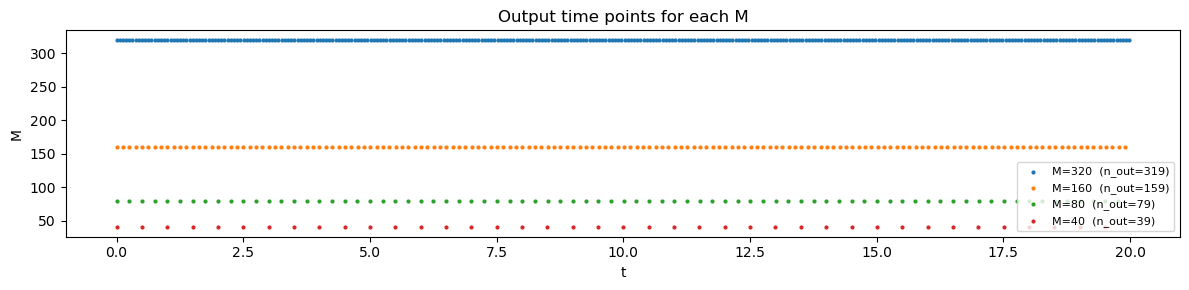

In [15]:
# ── t grid comparison ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
for row, (M, sol) in enumerate(solvers.items()):
    t_cpu = sol['t'].cpu()
    ax.scatter(t_cpu, [M]*len(t_cpu), s=4, label=f'M={M}  (n_out={len(t_cpu)-1})')
ax.set_xlabel('t')
ax.set_ylabel('M')
ax.set_title('Output time points for each M')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

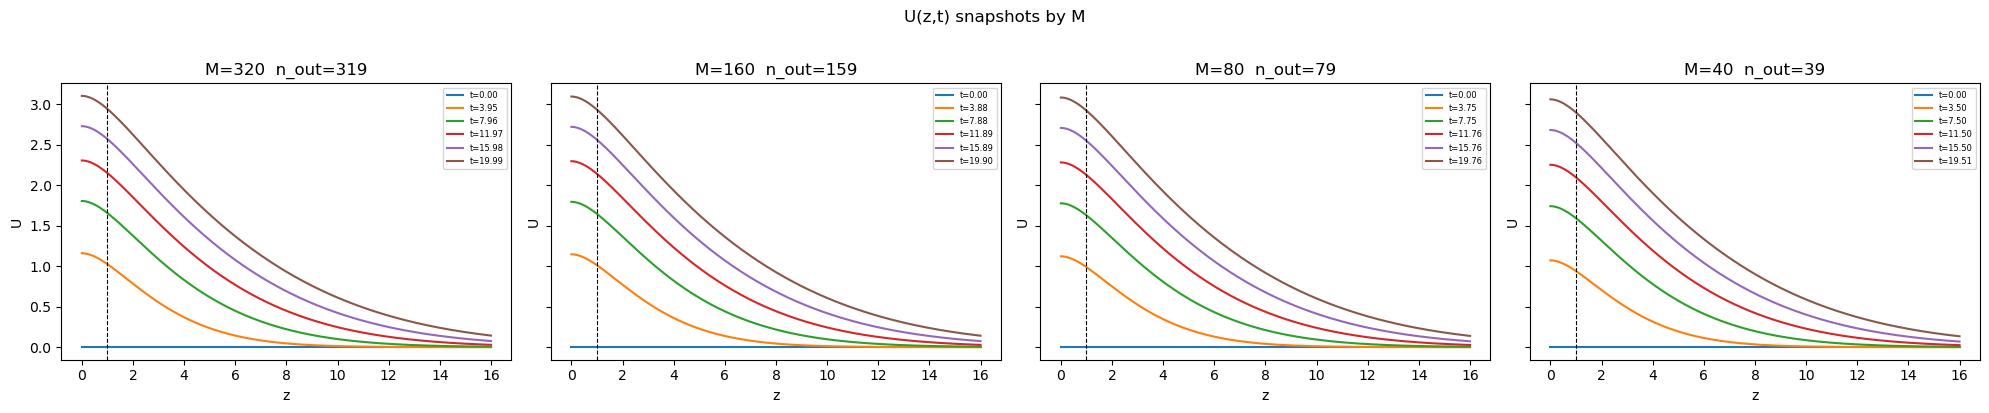

In [18]:
# ── U(z,t) snapshots for each M ─────────────────────────────────────────
n_M    = len(M_list)
fig, axes = plt.subplots(1, n_M, figsize=(5*n_M, 4), sharey=True)

for ax, (M, sol) in zip(axes, solvers.items()):
    U     = sol['U'].cpu()
    z_cpu = sol['z'].cpu()
    t_cpu = sol['t'].cpu()
    idx   = torch.linspace(0, len(t_cpu)-1, 6).long()
    for i in idx:
        ax.plot(z_cpu, U[:, i], label=f't={t_cpu[i]:.2f}')
    ax.axvline(z_dis, color='k', linestyle='--', lw=0.8)
    ax.set_xlabel('z'); ax.set_ylabel('U')
    ax.set_title(f'M={M}  n_out={len(t_cpu)-1}')
    ax.legend(fontsize=6)

plt.suptitle('U(z,t) snapshots by M', y=1.02)
plt.tight_layout(); plt.show()

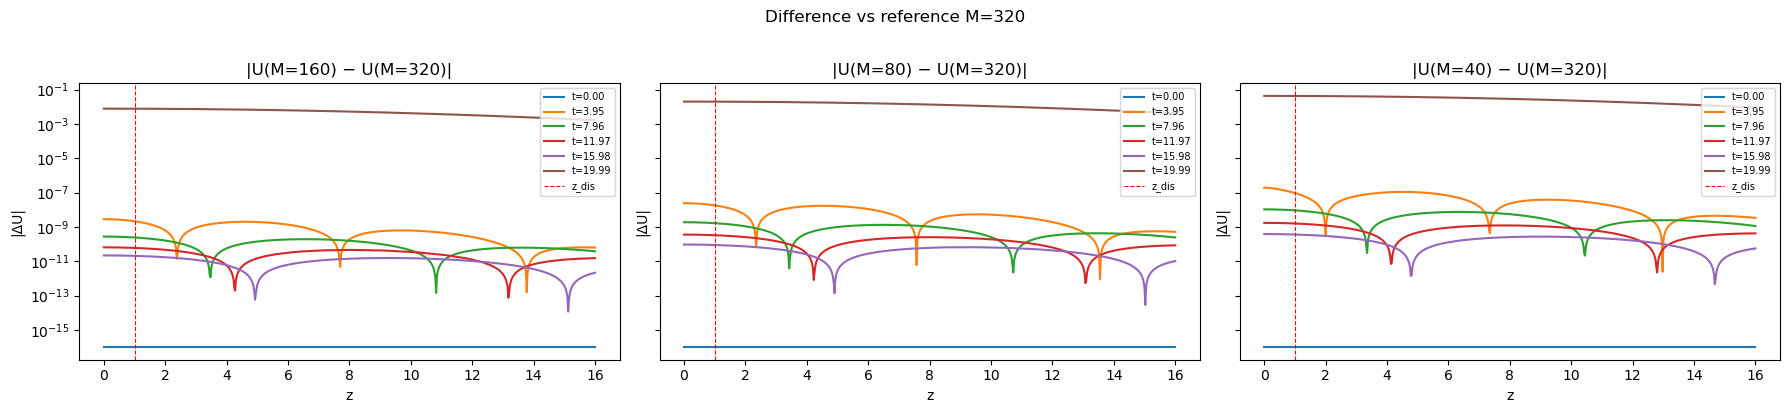

In [20]:
# ── difference vs M=320 (reference) ─────────────────────────────────────
M_ref  = M_list[0]                   # 320 is reference
sol_ref = solvers[M_ref]
z_ref   = sol_ref['z']
t_ref   = sol_ref['t']
U_ref   = sol_ref['U']

# build fine 2D query grid from reference
z_r2d, t_r2d = torch.meshgrid(z_ref, t_ref, indexing='ij')

n_cmp = len(M_list) - 1
if n_cmp > 0:
    fig, axes = plt.subplots(1, n_cmp, figsize=(6*n_cmp, 4), sharey=True)
    if n_cmp == 1: axes = [axes]

    for ax, M in zip(axes, M_list[1:]):
        sol  = solvers[M]
        U_M  = sol['interp_pw'](z_r2d, t_r2d)   # eval on ref t-grid
        err  = (U_M - U_ref).abs().cpu()
        idx  = torch.linspace(0, len(t_ref)-1, 6).long()
        for i in idx:
            ax.semilogy(z_ref.cpu(), err[:, i].clamp(min=1e-16),
                        label=f't={t_ref[i].item():.2f}')
        ax.axvline(z_dis, color='r', linestyle='--', lw=0.8, label='z_dis')
        ax.set_xlabel('z'); ax.set_ylabel('|ΔU|')
        ax.set_title(f'|U(M={M}) − U(M={M_ref})|')
        ax.legend(fontsize=7)

    plt.suptitle(f'Difference vs reference M={M_ref}', y=1.02)
    plt.tight_layout(); plt.show()